In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

In [4]:
# Load the daily data
df = pd.read_csv("Data.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print(df.head())
print("shape:", df.shape)
print("missing values by column:")
print(df.isna().sum())

# Check if any calendar dates are missing
all_days = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
missing_dates = all_days.difference(df["Date"])
print("missing calendar dates:", len(missing_dates))

        Date  Upstream Depth (ft)  Downstream Depth (ft)  \
0 2016-01-01             1.624416               7.003261   
1 2016-01-02             1.605676               7.059753   
2 2016-01-03             1.611514               7.043261   
3 2016-01-04             1.608600               7.000180   
4 2016-01-05             1.605676               6.966737   

   Upstream Mean Discharge (cfs)  Downstream Mean Discharge (cfs)  \
0                          137.0                            146.0   
1                          134.0                            147.0   
2                          136.0                            146.0   
3                          135.0                            144.0   
4                          134.0                            145.0   

   Upstream Width (ft)  Downstream Width (ft)  
0            58.532544              56.496681  
1            58.455077              56.519038  
2            58.506900              56.496681  
3            58.481079          

In [5]:
# Quick look at missing downstream depth dates
depth_missing = df["Downstream Depth (ft)"].isna()

# Find consecutive spans
spans = []
start = None
prev = None
for date, is_missing in zip(df["Date"], depth_missing):
    if is_missing and start is None:
        start = date
    if (not is_missing) and (start is not None):
        spans.append((start, prev, (prev - start).days + 1))
        start = None
    prev = date
if start is not None:
    spans.append((start, prev, (prev - start).days + 1))

spans_df = pd.DataFrame(spans, columns=["start", "end", "days"])
spans_df["year"] = spans_df["start"].dt.year
print(spans_df)

        start        end  days  year
0  2017-05-11 2017-05-17     7  2017
1  2017-08-15 2017-08-20     6  2017
2  2019-06-10 2019-06-23    14  2019
3  2019-08-15 2019-08-21     7  2019
4  2023-01-21 2023-01-24     4  2023
5  2023-05-04 2023-05-04     1  2023
6  2023-07-26 2023-07-30     5  2023
7  2024-08-03 2024-08-06     4  2024
8  2024-08-08 2024-08-15     8  2024
9  2024-08-17 2024-08-18     2  2024
10 2025-12-19 2025-12-22     4  2025


In [7]:
# Keep rows with usable inputs
input_cols = [
    "Upstream Depth (ft)",
    "Upstream Mean Discharge (cfs)",
    "Upstream Width (ft)",
    "Downstream Width (ft)",
]

# We also require downstream discharge for the current version
required_now = input_cols + ["Downstream Mean Discharge (cfs)"]

df_model = df.dropna(subset=required_now).copy()
df_model["depth_mask"] = (~df_model["Downstream Depth (ft)"].isna()).astype(int)

print("rows kept for modeling:", len(df_model))
print("rows with observed downstream depth:", int(df_model["depth_mask"].sum()))
print("rows with missing downstream depth but still usable:", int((df_model["depth_mask"] == 0).sum()))

rows kept for modeling: 3649
rows with observed downstream depth: 3591
rows with missing downstream depth but still usable: 58


In [39]:
# Train/test split by time
split_idx = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_idx].copy()
test_df = df_model.iloc[split_idx:].copy()

feature_cols = [
    "Upstream Depth (ft)",
    "Upstream Mean Discharge (cfs)",
    "Upstream Width (ft)",
    "Downstream Width (ft)",
]

# Add a simple time feature
train_df["time_index"] = np.arange(len(train_df))
test_df["time_index"] = np.arange(len(train_df), len(train_df) + len(test_df))

feature_cols_with_time = feature_cols + ["time_index"]

# Scale inputs only
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(train_df[feature_cols_with_time])
X_test = x_scaler.transform(test_df[feature_cols_with_time])

# Targets stay in physical units for easier interpretation
y_train_h = train_df["Downstream Depth (ft)"].to_numpy().reshape(-1, 1)
y_train_q = train_df["Downstream Mean Discharge (cfs)"].to_numpy().reshape(-1, 1)

y_test_h = test_df["Downstream Depth (ft)"].to_numpy().reshape(-1, 1)
y_test_q = test_df["Downstream Mean Discharge (cfs)"].to_numpy().reshape(-1, 1)

# Masks for missing downstream depth
mask_train_h = train_df["depth_mask"].to_numpy().reshape(-1, 1)
mask_test_h = test_df["depth_mask"].to_numpy().reshape(-1, 1)

# Raw physical values needed in the PDE loss
q_u_train = train_df["Upstream Mean Discharge (cfs)"].to_numpy().reshape(-1, 1)
h_u_train = train_df["Upstream Depth (ft)"].to_numpy().reshape(-1, 1)
b_d_train = train_df["Downstream Width (ft)"].to_numpy().reshape(-1, 1)

q_u_test = test_df["Upstream Mean Discharge (cfs)"].to_numpy().reshape(-1, 1)
h_u_test = test_df["Upstream Depth (ft)"].to_numpy().reshape(-1, 1)
b_d_test = test_df["Downstream Width (ft)"].to_numpy().reshape(-1, 1)

In [40]:
# Convert to torch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)

y_train_h_t = torch.tensor(np.nan_to_num(y_train_h, nan=0.0), dtype=torch.float32, device=device)
y_train_q_t = torch.tensor(y_train_q, dtype=torch.float32, device=device)

y_test_h_t = torch.tensor(np.nan_to_num(y_test_h, nan=0.0), dtype=torch.float32, device=device)
y_test_q_t = torch.tensor(y_test_q, dtype=torch.float32, device=device)

mask_train_h_t = torch.tensor(mask_train_h, dtype=torch.float32, device=device)
mask_test_h_t = torch.tensor(mask_test_h, dtype=torch.float32, device=device)

q_u_train_t = torch.tensor(q_u_train, dtype=torch.float32, device=device)
h_u_train_t = torch.tensor(h_u_train, dtype=torch.float32, device=device)
b_d_train_t = torch.tensor(b_d_train, dtype=torch.float32, device=device)

q_u_test_t = torch.tensor(q_u_test, dtype=torch.float32, device=device)
h_u_test_t = torch.tensor(h_u_test, dtype=torch.float32, device=device)
b_d_test_t = torch.tensor(b_d_test, dtype=torch.float32, device=device)

In [41]:
# Test setup
def finite_difference(y, dt):
    dy = torch.zeros_like(y)
    dy[1:-1] = (y[2:] - y[:-2]) / (2.0 * dt)
    dy[0] = (y[1] - y[0]) / dt
    dy[-1] = (y[-1] - y[-2]) / dt
    return dy

def continuity_residual(h_d, q_d, b_d, q_u):
    A_d = b_d * h_d
    dA_dt = finite_difference(A_d, DT_SEC)
    dQ_dx = (q_d - q_u) / DX_FT
    return dA_dt + dQ_dx

def momentum_residual(h_u, h_d, q_d, b_d, n_hat):
    A = b_d * h_d
    P = b_d + 2.0 * h_d
    R = A / (P + 1e-6)

    dQ_dt = finite_difference(q_d, DT_SEC)
    dh_dx = (h_d - h_u) / DX_FT

    # Simplified Manning friction slope
    Sf = (n_hat**2 * q_d**2) / ((A**2) * (R**(4.0 / 3.0)) + 1e-6)

    return dQ_dt + G * A * (dh_dx + Sf - S0)

In [42]:
# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

lambda_cont = 1e-4
lambda_mom = 1e-6
epochs = 1500

history = []

In [43]:
# Evaluate on the test period
model.eval()
with torch.no_grad():
    pred_h_test, pred_q_test, pred_n_test = model(X_test_t)

pred_h_test_np = pred_h_test.cpu().numpy().flatten()
pred_q_test_np = pred_q_test.cpu().numpy().flatten()
pred_n_test_np = pred_n_test.cpu().numpy().flatten()

results = test_df[["Date"]].copy()
results["Observed Downstream Depth (ft)"] = y_test_h.flatten()
results["Predicted Downstream Depth (ft)"] = pred_h_test_np
results["Observed Downstream Discharge (cfs)"] = y_test_q.flatten()
results["Predicted Downstream Discharge (cfs)"] = pred_q_test_np
results["Predicted Manning_n"] = pred_n_test_np

display(results.head())

,Date,Observed Downstream Depth (ft),Predicted Downstream Depth (ft),Observed Downstream Discharge (cfs),Predicted Downstream Discharge (cfs),Predicted Manning_n
2919,2023-12-29,6.997467,0.676136,161.0,0.720054,0.056595
2920,2023-12-30,7.003519,0.676441,162.0,0.720123,0.056578
2921,2023-12-31,7.003519,0.676462,162.0,0.720091,0.056577
2922,2024-01-01,7.003519,0.676483,162.0,0.720058,0.056576
2923,2024-01-02,7.037459,0.677449,166.0,0.720354,0.056576


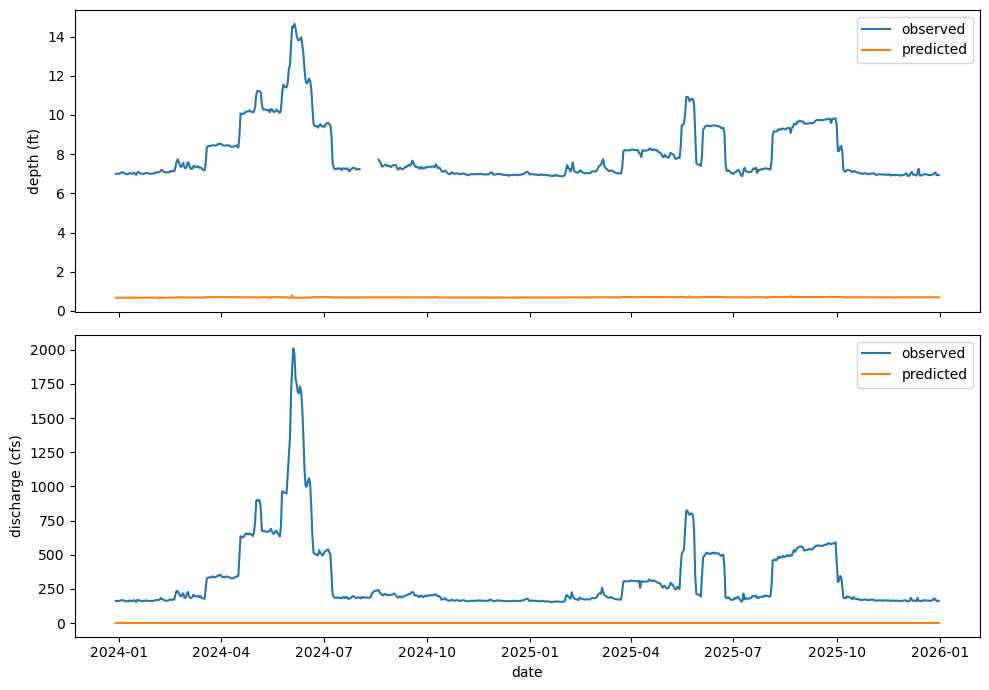

In [44]:
# Simple plots
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(results["Date"], results["Observed Downstream Depth (ft)"], label="observed")
axes[0].plot(results["Date"], results["Predicted Downstream Depth (ft)"], label="predicted")
axes[0].set_ylabel("depth (ft)")
axes[0].legend()

axes[1].plot(results["Date"], results["Observed Downstream Discharge (cfs)"], label="observed")
axes[1].plot(results["Date"], results["Predicted Downstream Discharge (cfs)"], label="predicted")
axes[1].set_ylabel("discharge (cfs)")
axes[1].legend()

plt.xlabel("date")
plt.tight_layout()
plt.show()

Missing downstream depth in 2019

-> kept the dates
-> used masked depth loss

PINN tuning

-> increase or decrease lambda_cont
-> increase or decrease lambda_mom